In [1]:
from utils import *
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Input
from tensorflow.keras.losses import Huber
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Bidirectional, LSTM 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback
import time
import json

Using cuda (NVIDIA GeForce RTX 2060)


In [2]:
# load data
df = load_df()
# calcula las fechas de los datasets de TRAIN, VAL y TEST
dates = calulate_train_validation_test_dates(df)
# scale df
df_scaled, target_scaler  = scale_df(df, dates)
# create rolling window for all features
df_scaled_window = window_df(df_scaled)
# split in train / validation / test
df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test = split_df(df_scaled_window, dates)
# create tensors 3d: (batch_size, sequence_length, n_features), (batch_size, 1)
X_train, y_train = to_tensor3d_df(df_scaled_window_train) 
X_validation, y_validation = to_tensor3d_df(df_scaled_window_validation)
X_test, y_test = to_tensor3d_df(df_scaled_window_test)

# log
print(X_train.shape) # expected: (batch_size, sequence_length, n_features)
print(y_train.shape) # expected  (batch_size, 1)
print(f"{y_train.mean():.8f}", f"{y_train.std():.8f}")
print(f"{y_validation.mean():.8f}", f"{y_validation.std():.8f}")
print(f"{y_test.mean():.8f}", f"{y_test.std():.8f}")


torch.Size([24406, 64, 15])
torch.Size([24406])
0.00053956 0.99916416
0.01545069 0.79186475
0.00306685 0.88971955


In [ ]:
# random predictor
class RandomDirection(nn.Module):
    def __init__(self, probs=None, device="cpu"):
        super().__init__()
        if probs is None:
            # default uniform over [-1, 0, 1]
            self.probs = torch.tensor([1/3, 1/3, 1/3], device=device)
        else:
            self.probs = torch.tensor(probs, device=device)
        self.classes = torch.tensor([-1, 0, 1], device=device)
        self.seed = 3

    def forward(self, x):
        #B = x.size(0)
        #idx = torch.multinomial(self.probs, B, replacement=True)
        #return self.classes[idx].unsqueeze(1)  # shape (B,1)
        if self.seed is not None:
            g = torch.Generator(device=x.device)
            g.manual_seed(self.seed)
            idx = torch.multinomial(self.probs, x.size(0), replacement=True, generator=g)
        else:
            idx = torch.multinomial(self.probs, x.size(0), replacement=True)
        return self.classes[idx].unsqueeze(1)

print (123)
    
    

123


In [4]:
# hyperparams
mean_value = y_train.mean().item()
loss_fn = nn.SmoothL1Loss()
learning_rate = 0.0001

# au
df_scaled_window_train["target_direction"] = [predict_direction(p) for p in df_scaled_window_train["target_log_return"]]
df_scaled_window_validation["target_direction"] = [predict_direction(p) for p in df_scaled_window_validation["target_log_return"]]
df_scaled_window_test["target_direction"] = [predict_direction(p) for p in df_scaled_window_test["target_log_return"]]
pct_up = (df_scaled_window_train["target_direction"] == 1).mean() 
pct_neutral = (df_scaled_window_train["target_direction"] == 0).mean() 
pct_down = (df_scaled_window_train["target_direction"] == -1).mean() 
probs = (pct_down, pct_neutral, pct_up)
print(probs)

# compile
model = RandomDirection(probs)

# start 
start = time.time()


# measure 
end = time.time()
metrics = {}
metrics["train_ms"] = (end - start)


(np.float64(0.21146439400147504), np.float64(0.5593296730312218), np.float64(0.22920593296730313))


In [ ]:
# predict

y_train_predict = model(X_train)

y_validation_predict = model(X_validation)

start = time.time()
y_test_predict = model(X_test)
metrics["test_predict_ms"] = (time.time() - start)

# append results to dataframes 
add_predictions_to_df(df_scaled_window_train, y_train_predict.squeeze(), target_scaler, df_scaled_window_train.iloc[0]["close"])
add_predictions_to_df(df_scaled_window_validation, y_validation_predict.squeeze(), target_scaler, df_scaled_window_validation.iloc[0]["close"])
add_predictions_to_df(df_scaled_window_test, y_test_predict.squeeze(), target_scaler, df_scaled_window_validation.iloc[-1]["predict_close_accumulated"])





In [6]:
# eval metrics
metrics["train"] = evaluate_metrics_df(df_scaled_window_train)
metrics["validation"] = evaluate_metrics_df(df_scaled_window_validation)
metrics["test"] = evaluate_metrics_df(df_scaled_window_test)

# show
print(json.dumps(metrics, indent=4) )


{
    "train_ms": 0.0,
    "test_predict_ms": 0.0,
    "train": {
        "mse": 9.616739949017907e-06,
        "rmse": 0.0031010868980113904,
        "mae": 0.0020696220587907124,
        "huber": 4.8083699745089534e-06,
        "r2": -0.4618337612265022,
        "mape": null,
        "smape": null,
        "aic": null,
        "bic": null,
        "pearson_r": -0.01553196033571454,
        "spearman_rho": -0.008137385850099868,
        "direction": 40.658034909448496,
        "sharpe": -0.015318593530984494
    },
    "validation": {
        "mse": 6.955189946892671e-06,
        "rmse": 0.0026372694111320275,
        "mae": 0.0018016684154217053,
        "huber": 3.4775949734463354e-06,
        "r2": -0.6835113306383775,
        "mape": null,
        "smape": null,
        "aic": null,
        "bic": null,
        "pearson_r": 0.015670641514716883,
        "spearman_rho": 0.011711339836354756,
        "direction": 41.66666666666667,
        "sharpe": 0.01504541181151506
    },
    "t

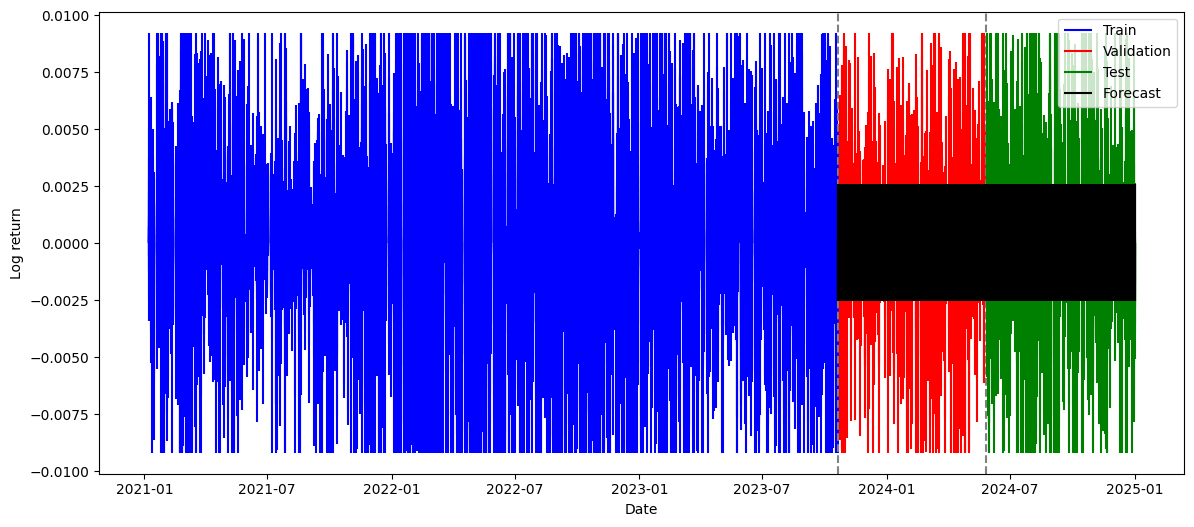

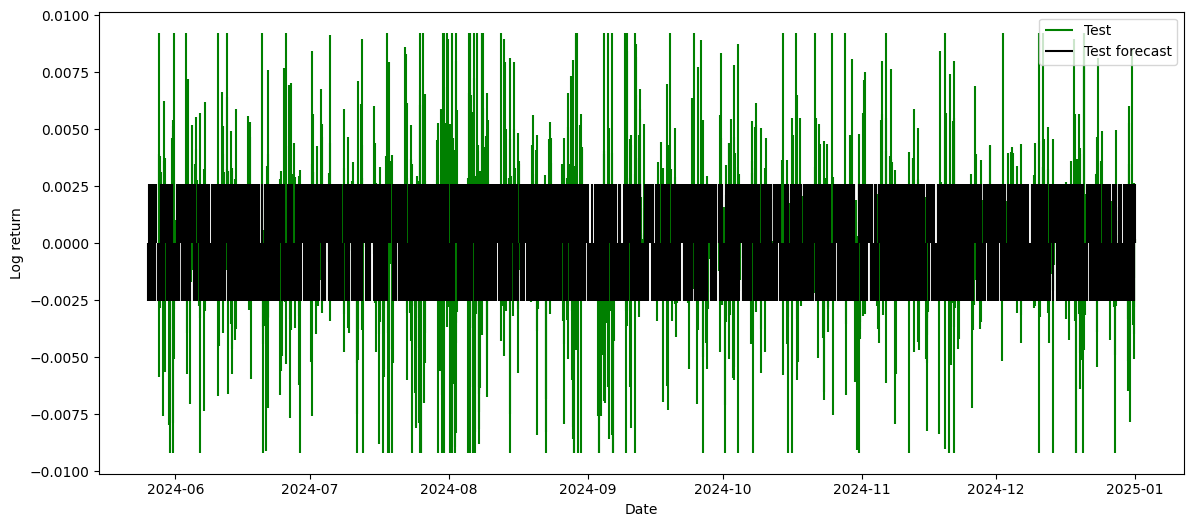

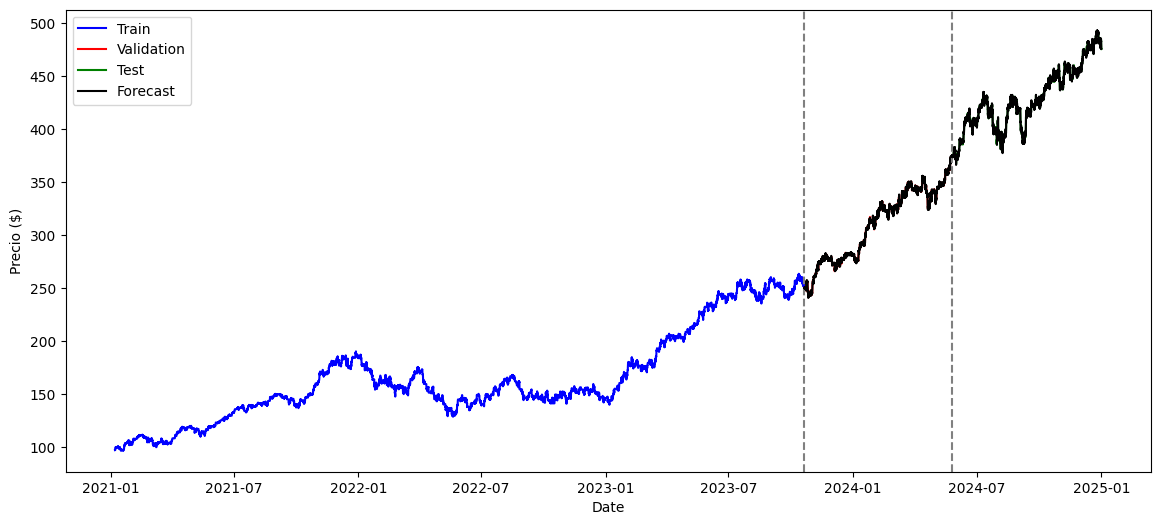

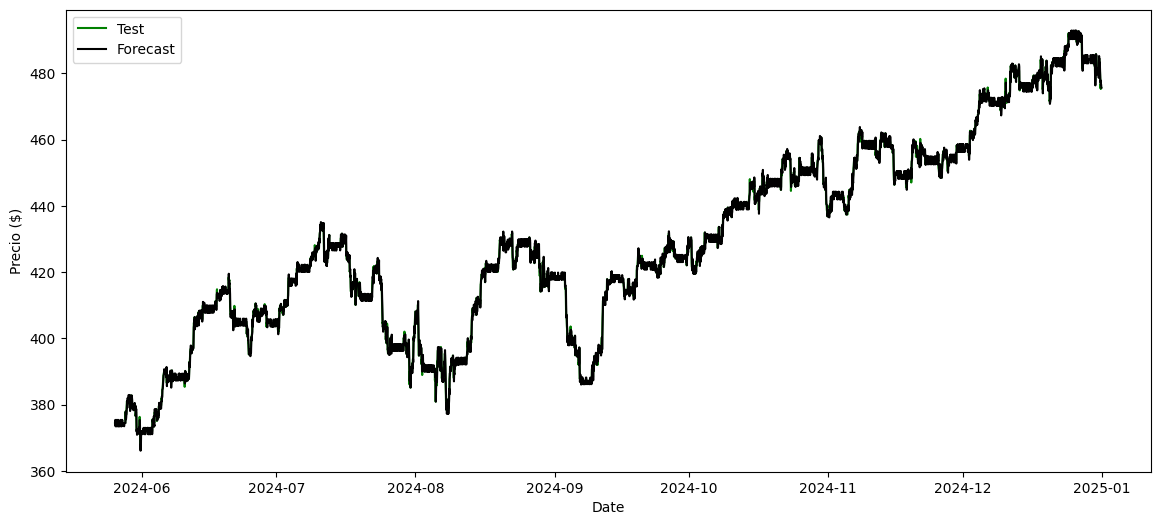

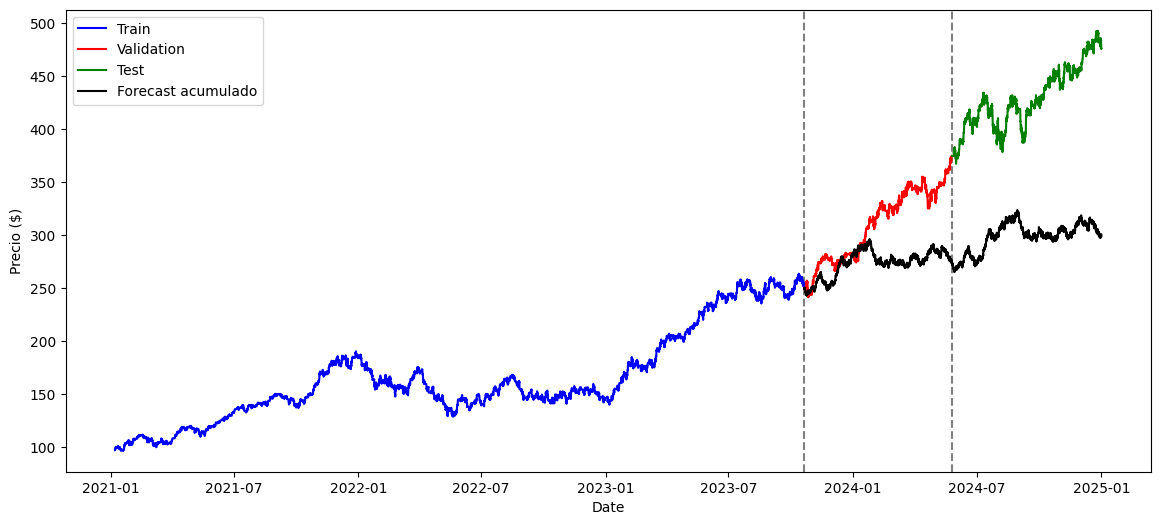

In [7]:
# plot
plot_df(df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test, False)



In [8]:
# Suppose y_dir contains your direction labels (-1, 0, +1)
unique, counts = np.unique(df_scaled_window_test[["target_direction"]].to_numpy(), return_counts=True)
probs = counts / counts.sum()

print("Class distribution:")
for u, p in zip(unique, probs):
    print(f"{u}: {p:.2%}")

# Suppose y_dir contains your direction labels (-1, 0, +1)
unique, counts = np.unique(df_scaled_window_test[["predict_direction"]].to_numpy(), return_counts=True)
probs = counts / counts.sum()

print("Class distribution PREDICT:")
for u, p in zip(unique, probs):
    print(f"{u}: {p:.2%}")    

Class distribution:
-1: 20.52%
0: 56.75%
1: 22.73%
Class distribution PREDICT:
-1: 22.60%
0: 55.58%
1: 21.82%


In [9]:
from scipy.stats import f_oneway

anova_result = f_oneway(
    df_scaled_window_train["error_log_return_square"],
    df_scaled_window_validation["error_log_return_square"],
    df_scaled_window_test["error_log_return_square"]
)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)



F-statistic: 45.64368733530775
p-value: 1.5961293037908513e-20


In [10]:
# save 
save_result("baseline_random_distribution", metrics, df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test)